# Лаб4: Decision Tree / Random Forest / Gradient Boosting


In [1]:
import os
import sys
from pathlib import Path

sys.path.append(str(Path('..').resolve()))

import pickle

import numpy as np
import torch
import pandas as pd

import matplotlib.pyplot as plt

from src.models import DecisionTree, RandomForest, GradientBoosting

np.set_printoptions(precision=4, suppress=True)


In [2]:
import numpy as np
import torch
import pandas as pd


def train_test_split(
    X,
    y,
    test_size: float = 0.2,
    random_state: int = 42,
    shuffle: bool = True,
    stratify=None,
):
    rng = np.random.default_rng(random_state)
    X = np.asarray(X)
    y = np.asarray(y)

    n = len(X)
    if n != len(y):
        raise ValueError("X and y must have the same length")

    if stratify is None:
        idx = np.arange(n)
        if shuffle:
            rng.shuffle(idx)
        n_test = int(n * test_size)
        test_idx = idx[:n_test]
        train_idx = idx[n_test:]
        return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

    stratify = np.asarray(stratify)
    if len(stratify) != n:
        raise ValueError("stratify must have the same length as X")

    train_idx, test_idx = [], []
    for cls in np.unique(stratify):
        cls_idx = np.where(stratify == cls)[0]
        if shuffle:
            rng.shuffle(cls_idx)
        n_test = int(len(cls_idx) * test_size)
        test_idx.extend(cls_idx[:n_test])
        train_idx.extend(cls_idx[n_test:])

    train_idx = np.array(train_idx, dtype=int)
    test_idx = np.array(test_idx, dtype=int)
    if shuffle:
        rng.shuffle(train_idx)
        rng.shuffle(test_idx)
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


def preprocess_london(csv_path: str):
    df = pd.read_csv(csv_path)
    print("Raw shape:", df.shape)
    print("Columns:", df.columns.tolist())

    df = df.dropna().reset_index(drop=True)
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    df["hour"] = df["timestamp"].dt.hour
    df["dayofweek"] = df["timestamp"].dt.dayofweek
    df["month"] = df["timestamp"].dt.month

    y = df["cnt"].astype(np.float32).values

    feature_cols = [
        "t1",
        "t2",
        "hum",
        "wind_speed",
        "weather_code",
        "is_holiday",
        "is_weekend",
        "season",
        "hour",
        "dayofweek",
        "month",
    ]

    X = df[feature_cols].astype(np.float32).values

    print("Used features:", feature_cols)
    print("X shape:", X.shape, "y shape:", y.shape)

    return X, y, feature_cols


def load_london(csv_path: str, test_size: float = 0.2, random_state: int = 42):
    X, y, feature_cols = preprocess_london(csv_path)

    X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        shuffle=True,
    )

    mean = X_train_np.mean(axis=0)
    std = X_train_np.std(axis=0)
    std[std == 0] = 1.0

    X_train_np = (X_train_np - mean) / std
    X_test_np = (X_test_np - mean) / std

    X_train = torch.from_numpy(X_train_np.astype(np.float32))
    X_test = torch.from_numpy(X_test_np.astype(np.float32))

    y_train = torch.from_numpy(y_train_np.astype(np.float32)).view(-1, 1)
    y_test = torch.from_numpy(y_test_np.astype(np.float32)).view(-1, 1)

    stats = {
        "mean": torch.from_numpy(mean.astype(np.float32)),
        "std": torch.from_numpy(std.astype(np.float32)),
        "feature_cols": feature_cols,
    }

    return X_train, y_train, X_test, y_test, stats


import os
import pickle


def _load_cifar_batch(file_path: str):
    with open(file_path, "rb") as f:
        batch = pickle.load(f, encoding="latin1")
    data = batch["data"]
    labels = batch["labels"]
    print(len(data), len(labels))

    data = data.reshape(-1, 3, 32, 32)
    labels = np.array(labels, dtype=np.int64)

    return data, labels


def preprocess_cifar10(root_dir: str):
    train_data_list = []
    train_labels_list = []

    for i in range(1, 6):
        batch_path = os.path.join(root_dir, f"data_batch_{i}")
        data, labels = _load_cifar_batch(batch_path)
        train_data_list.append(data)
        train_labels_list.append(labels)

    X = np.concatenate(train_data_list, axis=0)
    y = np.concatenate(train_labels_list, axis=0)

    print("CIFAR-10 train X shape:", X.shape)
    print("CIFAR-10 train y shape:", y.shape)

    meta_path = os.path.join(root_dir, "batches.meta")
    label_names = None
    if os.path.exists(meta_path):
        with open(meta_path, "rb") as f:
            meta = pickle.load(f, encoding="latin1")
        label_names = meta.get("label_names", None)
        print("Label names:", label_names)

    X = X.astype(np.float32)

    return X, y, label_names


def load_cifar10(
    root_dir: str,
    test_size: float = 0.2,
    random_state: int = 42,
    binary_classes: tuple[int, int] | None = None,
    max_samples: int | None = 10000,
):
    X_np, y_np, label_names = preprocess_cifar10(root_dir)

    if binary_classes is not None:
        c0, c1 = binary_classes
        mask = (y_np == c0) | (y_np == c1)
        X_np = X_np[mask]
        y_np = y_np[mask]
        y_np = (y_np == c0).astype(np.int64)  # {0,1}
        print(f"Binary classes {binary_classes}: X={X_np.shape} y={y_np.shape}")

    if max_samples is not None and max_samples < len(X_np):
        X_np = X_np[:max_samples]
        y_np = y_np[:max_samples]
        print(f"Truncated to {max_samples} samples for speed")

    X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
        X_np,
        y_np,
        test_size=test_size,
        random_state=random_state,
        shuffle=True,
        stratify=y_np,
    )

    X_train_float = X_train_np / 255.0
    X_test_float = X_test_np / 255.0

    mean = X_train_float.mean(axis=(0, 2, 3))
    std = X_train_float.std(axis=(0, 2, 3))
    std[std == 0] = 1.0

    X_train_norm = (X_train_float - mean[None, :, None, None]) / std[None, :, None, None]
    X_test_norm = (X_test_float - mean[None, :, None, None]) / std[None, :, None, None]

    N_train = X_train_norm.shape[0]
    N_test = X_test_norm.shape[0]

    X_train_norm = X_train_norm.reshape(N_train, -1)
    X_test_norm = X_test_norm.reshape(N_test, -1)

    X_train = torch.from_numpy(X_train_norm.astype(np.float32))
    X_test = torch.from_numpy(X_test_norm.astype(np.float32))

    y_train = torch.from_numpy(y_train_np.astype(np.int64))
    y_test = torch.from_numpy(y_test_np.astype(np.int64))

    stats = {
        "mean": torch.from_numpy(mean.astype(np.float32)),
        "std": torch.from_numpy(std.astype(np.float32)),
        "label_names": label_names,
    }

    return X_train, y_train, X_test, y_test, stats


def _to_np(arr):
    if torch.is_tensor(arr):
        return arr.detach().cpu().numpy()
    return np.asarray(arr)


def rmse(y_true, y_pred):
    yt = _to_np(y_true)
    yp = _to_np(y_pred)
    return float(np.sqrt(np.mean((yt - yp) ** 2)))


def accuracy(y_true, y_pred):
    yt = _to_np(y_true)
    yp = _to_np(y_pred)
    return float((yt == yp).mean())


## Регрессия: London bike sharing


In [3]:
X_train, y_train, X_test, y_test, stats = load_london('../datasets/london_merged.csv')
X_train.shape, X_test.shape

Raw shape: (17414, 10)
Columns: ['timestamp', 'cnt', 't1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season']
Used features: ['t1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season', 'hour', 'dayofweek', 'month']
X shape: (17414, 11) y shape: (17414,)


(torch.Size([13932, 11]), torch.Size([3482, 11]))

In [11]:
models_reg = {
    'tree': DecisionTree(max_depth=8, min_samples_leaf=5, classification=False, random_state=0),
    'rf': RandomForest(n_estimators=60, max_depth=12, min_samples_leaf=3, max_features='sqrt', classification=False, random_state=1),
    'gb': GradientBoosting(n_estimators=150, learning_rate=0.05, max_depth=3, subsample=0.7, classification=False, random_state=2),
}

rmse_scores = {}
for name, model in models_reg.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse_scores[name] = rmse(y_test, pred)
    print(f'{name}: RMSE={rmse_scores[name]:.2f}')

rmse_scores

tree: RMSE=1502.46
rf: RMSE=1401.81
gb: RMSE=1413.48


{'tree': 1502.4633991798707,
 'rf': 1401.8147479327438,
 'gb': 1413.4824563431673}

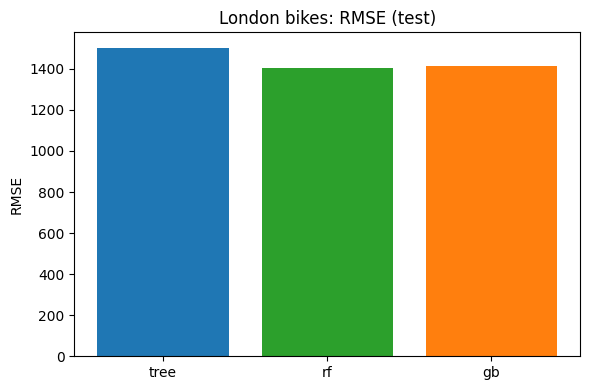

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(list(rmse_scores.keys()), list(rmse_scores.values()), color=['tab:blue','tab:green','tab:orange'])
plt.ylabel('RMSE')
plt.title('London bikes: RMSE (test)')
plt.tight_layout()
plt.show()


## Классификация: CIFAR-10 (10 классов)



In [6]:
X_train_c, y_train_c, X_test_c, y_test_c, cifar_stats = load_cifar10(
    '../datasets/cifar-10-batches-py',
    test_size=0.2,
    random_state=42,
    binary_classes=None,
    max_samples=5000,
)
X_train_c.shape, X_test_c.shape


10000 10000
10000 10000
10000 10000
10000 10000
10000 10000
CIFAR-10 train X shape: (50000, 3, 32, 32)
CIFAR-10 train y shape: (50000,)
Label names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Truncated to 5000 samples for speed


(torch.Size([4004, 3072]), torch.Size([996, 3072]))

In [ ]:
models_clf = {
    'tree': DecisionTree(max_depth=16, max_features='sqrt', classification=True, random_state=0),
    'rf': RandomForest(n_estimators=60, max_depth=22, max_features='sqrt', classification=True, random_state=1),
    'gb': GradientBoosting(n_estimators=15, learning_rate=0.2, max_depth=3, subsample=0.8, classification=True, random_state=2),
}

acc_scores = {}
for name, model in models_clf.items():
    model.fit(X_train_c, y_train_c)
    pred = model.predict(X_test_c)
    acc_scores[name] = accuracy(y_test_c, pred)
    print(f'{name}: acc={acc_scores[name]:.3f}')

acc_scores


tree: acc=0.226
rf: acc=0.355
gb: acc=0.323


{'tree': 0.22590361445783133,
 'rf': 0.35542168674698793,
 'gb': 0.3232931726907631}

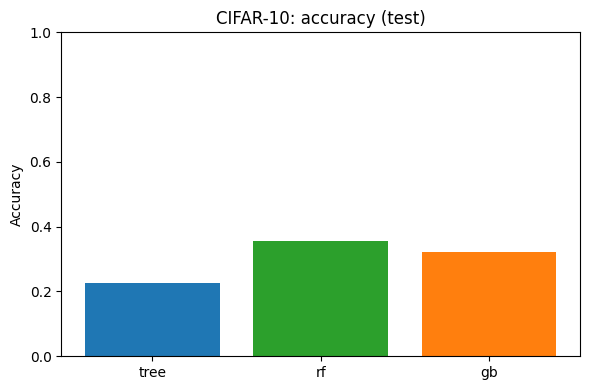

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(list(acc_scores.keys()), list(acc_scores.values()), color=['tab:blue','tab:green','tab:orange'])
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.title('CIFAR-10: accuracy (test)')
plt.tight_layout()
plt.show()
